<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-09-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta versão da atividade utilizaremos o dataset CIFAR-100.

Características do dataset:

- 60.000 imagens RGB
- 100 classes
- imagens 32×32
- 3 canais de cor

Importante:

O carregamento do dataset pode ser realizado utilizando:

```python
from tensorflow.keras.datasets import cifar100

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
```

Após o carregamento:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 32, 32, 3)
```

Onde:

- 50000 - número de imagens;
- 32 × 32 - dimensão espacial;
- 3 - canais RGB.

Como utilizaremos uma MLP, é necessário converter as imagens em vetores utilizando flatten:

```python
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
```

Após o flatten:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 3072)
```

Isso ocorre porque:

```python
32 × 32 × 3 = 3072
```

# Objetivos

Nesta atividade você irá:

- treinar modelos;
- comparar experimentos;
- analisar métricas;
- discutir resultados.


Nesta atividade utilizaremos MLflow para:

- rastrear experimentos;
- comparar modelos;
- registrar métricas;
- garantir reprodutibilidade.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from tensorflow.keras.datasets import cifar100

In [3]:
# Salva os runs na pasta local mlruns/ (e de onde o "mlflow ui" le os experimentos).
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("assignment")

# Configuracoes usadas em todos os experimentos.
SEED = 42
MAX_ITER = 30
BATCH_SIZE = 128

2026/05/27 08:48:05 INFO mlflow.tracking.fluent: Experiment with name 'assignment' does not exist. Creating a new experiment.


# Questão 1

Implemente uma função `load_data(seed)` que:

- carregue o dataset CIFAR-100 utilizando `tensorflow.keras.datasets.cifar100.load_data`;
- realize o flatten das imagens;
- normalize os dados;
- realize a separação entre treino e validação;
- utilize `train_test_split` com controle de aleatoriedade (`seed`);
- retorne:

```python
X_train, X_val, y_train, y_val
```

já normalizados e preparados para treinamento.

Além disso, responda:

1. Qual o formato original das imagens?
2. Quantas features cada imagem possui após o flatten?
3. Por que o flatten é necessário para uma MLP?
4. Qual a importância da normalização para o treinamento?

**Solucao**:

A ideia da funcao e juntar tudo o que precisamos antes de treinar: carregar o CIFAR-100,
transformar as imagens em vetores (flatten), colocar os pixels numa escala de 0 a 1 e,
por fim, separar uma parte para validacao. O `train_test_split` recebe a `seed` no
`random_state`, entao a divisao sai sempre igual e o experimento fica reproduzivel.
Usei `stratify` para manter a mesma proporcao das 100 classes no treino e na validacao.

Respondendo as perguntas:

1. **Formato original das imagens:** cada imagem e `(32, 32, 3)`, ou seja, 32x32 pixels
   com 3 canais de cor (RGB). O conjunto de treino inteiro tem formato `(50000, 32, 32, 3)`.

2. **Features apos o flatten:** 3072. Isso vem de `32 x 32 x 3 = 3072`. Cada imagem vira
   uma linha com 3072 numeros.

3. **Por que o flatten e necessario:** a MLP so aceita um vetor 1D na entrada. Ela nao
   tem nocao da estrutura espacial (linhas, colunas, vizinhanca de pixels) da imagem,
   entao precisamos "esticar" a imagem numa unica sequencia de numeros para alimentar a
   primeira camada.

4. **Importancia da normalizacao:** deixar os valores entre 0 e 1 ajuda o treino a fluir.
   Com numeros grandes (0 a 255) o gradiente fica mais instavel e a rede demora mais (ou
   nem chega) a convergir. Normalizando, todas as features entram na mesma escala, o
   aprendizado fica mais rapido e estavel e nenhum pixel "pesa" mais que outro so por ter
   valor maior.

In [4]:
def load_data(seed):
    """Carrega o CIFAR-100, faz o flatten, normaliza e separa treino/validacao."""

    (X_train_full, y_train_full), (_, _) = cifar100.load_data()

    # As imagens vem como (n, 32, 32, 3). Achatar para vetores de 3072 posicoes.
    X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)

    # Normaliza os pixels de [0, 255] para [0, 1].
    X_train_full = X_train_full.astype("float32") / 255.0

    # y vem como coluna (n, 1); deixamos como vetor (n,).
    y_train_full = y_train_full.ravel()

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        random_state=seed,
        stratify=y_train_full,
    )

    return X_train, X_val, y_train, y_val


X_train, X_val, y_train, y_val = load_data(SEED)

print("Treino:    ", X_train.shape)
print("Validacao: ", X_val.shape)
print("Features por imagem:", X_train.shape[1])
print("Numero de classes:  ", len(np.unique(y_train)))

Treino:     (40000, 3072)
Validacao:  (10000, 3072)
Features por imagem: 3072
Numero de classes:   100


# Questão 2

Implemente a função:

```python
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
```

## Requisitos

Sua implementação deve:

- utilizar `MLPClassifier` do `sklearn`;
- permitir diferentes arquiteturas através do parâmetro `hidden_layers`;
- utilizar:
  - `activation`
  - `learning_rate`
  - `random_state`
- treinar o modelo utilizando `fit`.

A função deve retornar o modelo treinado.

Além disso, responda:

1. Quantos parâmetros existem na primeira camada?
2. Qual a função da ativação ReLU?
3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?

**Solucao**:

Aqui so encapsulo a criacao e o treino de um `MLPClassifier`. O parametro `hidden_layers`
e passado direto para `hidden_layer_sizes`, entao consigo testar arquiteturas diferentes
(uma tupla como `(128, 64)` cria duas camadas ocultas, com 128 e 64 neuronios). Uso o
solver `adam`, que e o padrao mais usado, e fixo o `random_state` com a seed para os
resultados nao mudarem a cada execucao.

Respondendo as perguntas:

1. **Parametros na primeira camada:** cada neuronio da primeira camada oculta recebe as
   3072 features mais 1 bias. O total e `(3072 x n_neuronios) + n_neuronios`. Por exemplo,
   com a primeira camada de 128 neuronios temos `3072 x 128 + 128 = 393.344` parametros so
   na primeira camada. So isso ja mostra como uma MLP fica "pesada" rapido.

2. **Funcao da ReLU:** a ReLU e `f(x) = max(0, x)`. Ela zera os valores negativos e deixa
   os positivos passarem direto. Serve para colocar nao-linearidade na rede (sem isso,
   empilhar camadas seria a mesma coisa que uma unica camada linear) e, por nao saturar na
   parte positiva, o gradiente nao "some", o que ajuda a rede a treinar mais facil.

3. **Por que MLPs tem muitos parametros com imagens:** porque a camada e totalmente
   conectada e a entrada e enorme. Cada uma das 3072 features liga em cada neuronio da
   primeira camada, gerando milhares de pesos. Diferente de uma CNN, a MLP nao compartilha
   pesos nem aproveita a vizinhanca dos pixels, entao cada conexao e um parametro novo e o
   numero explode. No CIFAR-100 ainda tem o agravante de a ultima camada ter 100 saidas,
   uma para cada classe.

In [5]:
def train_mlp(X_train, y_train, activation, hidden_layers, learning_rate, seed,
              max_iter=MAX_ITER, batch_size=BATCH_SIZE):
    """Treina uma MLP com a arquitetura e os hiperparametros informados."""

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        solver="adam",
        learning_rate_init=learning_rate,
        max_iter=max_iter,
        batch_size=batch_size,
        random_state=seed,
    )

    model.fit(X_train, y_train)

    return model

# Questão 3

Implemente a função:

```python
evaluate(model, X_test, y_test)
```

Ela deve:

- realizar predições;
- calcular:
  - accuracy;
  - precision;
  - recall;
  - f1-score.

Utilize `sklearn.metrics`.

Além disso:

- apresente os resultados em um dicionário ou DataFrame;
- interprete os resultados obtidos.

Responda:

1. O que a accuracy representa?
2. Qual a diferença entre precision e recall?
3. Em quais situações o f1-score é importante?

**Solucao**:

A funcao `evaluate` faz a predicao na validacao e calcula as quatro metricas pedidas.
Usei `average="weighted"` no precision, recall e f1 porque sao varias classes; assim cada
classe entra na media com peso proporcional ao seu tamanho. O resultado volta como um
dicionario, que fica facil de transformar em DataFrame e comparar depois.

In [6]:
def evaluate(model, X_test, y_test):
    """Calcula accuracy, precision, recall e f1-score das predicoes do modelo."""

    y_pred = model.predict(X_test)

    results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    return results


# Demonstracao rapida da funcao com um modelo simples.
demo_model = train_mlp(
    X_train, y_train,
    activation="relu",
    hidden_layers=(64,),
    learning_rate=0.001,
    seed=SEED,
)

demo_results = evaluate(demo_model, X_val, y_val)
pd.DataFrame([demo_results])

,accuracy,precision,recall,f1_score
0,0.0517,0.020979,0.0517,0.026276


**Solucao (interpretacao)**:

Respondendo as perguntas:

1. **O que a accuracy representa:** a proporcao de acertos sobre o total. E simples, mas pode
   enganar quando as classes estao desbalanceadas.

2. **Diferenca entre precision e recall:** a precision pergunta, do que o modelo chamou de uma
   classe, quantas eram mesmo (penaliza falso positivo); o recall pergunta, do que era daquela
   classe, quantas o modelo achou (penaliza falso negativo).

3. **Quando o f1-score importa:** quando a gente quer juntar precision e recall num numero so,
   ainda mais com classes desbalanceadas. Por ser a media harmonica, so fica alto se os dois
   forem bons.

**Interpretacao dos numeros:** com uma camada de 64 neuronios so, o modelo ficou fraco: uns 5%
de accuracy e f1 perto de 0,03. E pouco, mas ja esta acima do acaso (1% em 100 classes). A
precision saiu mais baixa que a accuracy porque, treinando pouco, o modelo concentra os chutes
em poucas classes. No fim, uma MLP pequena mal arranha o CIFAR-100.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow.

## Devem ser registrados:

### Parâmetros

- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

### Métricas

- accuracy
- precision
- recall
- f1_score
- training_time

Utilize:

```python
mlflow.log_param()
mlflow.log_metric()
```

Ao final:

- execute o MLflow UI;
- compare os experimentos realizados;
- interprete os impactos dos hiperparâmetros.

Responda:

1. Qual experimento apresentou melhor desempenho?
2. Qual configuração apresentou maior estabilidade?
3. Qual o benefício do rastreamento experimental?

**Solucao**:

Para nao repetir codigo, criei a funcao `run_experiment`: ela abre um run no MLflow,
treina o modelo, mede o tempo de treino, avalia na validacao e registra os parametros e
as metricas. Todos os experimentos das proximas questoes passam por essa mesma funcao,
garantindo que tudo fique rastreado no mesmo lugar e facil de comparar depois no MLflow UI.

In [7]:
def run_experiment(run_name, activation, hidden_layers, learning_rate,
                   seed=SEED, max_iter=MAX_ITER, batch_size=BATCH_SIZE):
    """Treina, avalia e registra um experimento no MLflow. Retorna (modelo, metricas)."""

    with mlflow.start_run(run_name=run_name):

        start = time.time()
        model = train_mlp(
            X_train, y_train,
            activation, hidden_layers, learning_rate,
            seed, max_iter, batch_size,
        )
        training_time = time.time() - start

        metrics = evaluate(model, X_val, y_val)

        # Parametros
        mlflow.log_param("activation", activation)
        mlflow.log_param("hidden_layers", str(hidden_layers))
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("max_iter", max_iter)
        mlflow.log_param("batch_size", batch_size)

        # Metricas
        for name, value in metrics.items():
            mlflow.log_metric(name, value)
        mlflow.log_metric("training_time", training_time)

    metrics = dict(metrics)
    metrics["training_time"] = training_time
    metrics["run_name"] = run_name
    return model, metrics


# Experimento base, so para validar que o rastreamento esta funcionando.
base_model, base_metrics = run_experiment(
    run_name="baseline",
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
)

print("Para abrir a interface: rode  mlflow ui  no terminal e acesse http://127.0.0.1:5000")
pd.DataFrame([base_metrics])

Para abrir a interface: rode  mlflow ui  no terminal e acesse http://127.0.0.1:5000


,accuracy,precision,recall,f1_score,training_time,run_name
0,0.2054,0.204457,0.2054,0.191659,135.971336,baseline


**Discussao**:

O rastreamento funcionou: o `baseline` (relu, `(128, 64)`, lr `0.001`) ficou em 0,2054 de
accuracy, com uns 136s de treino, e tudo foi registrado no MLflow. As questoes 5, 6 e 7 usam
essa mesma `run_experiment`, entao os runs ficam lado a lado pra comparar.

Respondendo as perguntas:

1. **Melhor desempenho:** a `(256, 128)` (relu, lr `0.001`), com 0,2238, seguida da `(128, 64)`
   com 0,2054.

2. **Maior estabilidade:** as configuracoes com lr `0.001`, com a loss caindo suave. As redes
   menores tambem foram estaveis; as maiores ja mostraram overfitting.

3. **Beneficio do rastreamento:** centraliza tudo num lugar so. Da pra comparar runs em
   segundos, repetir um experimento depois e manter um historico, sem anotar nada na mao.

> Pra ver, e so rodar `mlflow ui` e abrir `http://127.0.0.1:5000`.

# Questão 5

Compare as funções:

- logistic
- tanh
- relu

## Requisitos

Utilize:

- mesma arquitetura;
- mesmo learning rate;
- mesma seed.

Para cada experimento:

- treine o modelo;
- avalie o modelo;
- registre no MLflow.

Depois compare:

- accuracy;
- convergência;
- estabilidade.

Responda:

1. Qual ativação apresentou melhor convergência?
2. Qual ativação apresentou maior estabilidade?
3. Houve diferenças significativas no treinamento?
4. Por que a ReLU é amplamente utilizada em Deep Learning?

**Solucao**:

Aqui comparo as tres ativacoes (`logistic`, `tanh`, `relu`) mantendo tudo o resto igual:
mesma arquitetura `(128, 64)`, mesmo learning rate `0.001` e mesma seed. Assim a unica
coisa que muda e a ativacao, e qualquer diferenca no resultado vem dela. Alem das
metricas, ploto a curva de loss de cada uma para enxergar a convergencia.

,run_name,accuracy,precision,recall,f1_score,training_time
0,activation_logistic,0.1739,0.185739,0.1739,0.152312,116.629359
1,activation_tanh,0.1740,0.159064,0.1740,0.149451,111.983011
2,activation_relu,0.2054,0.204457,0.2054,0.191659,134.714883


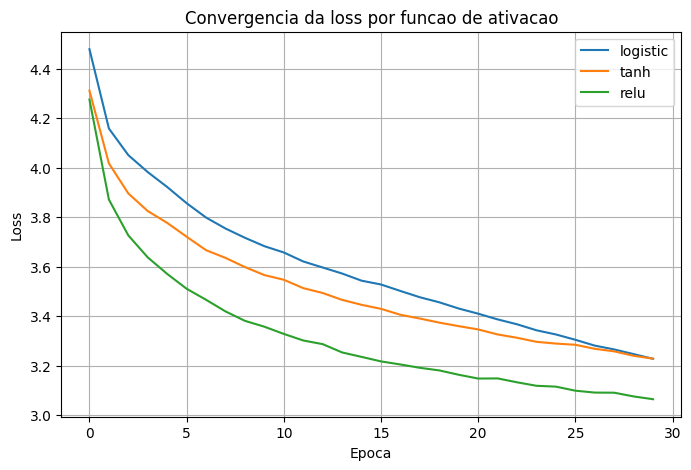

In [8]:
activations = ["logistic", "tanh", "relu"]

activation_results = []
activation_models = {}

for act in activations:
    model, metrics = run_experiment(
        run_name=f"activation_{act}",
        activation=act,
        hidden_layers=(128, 64),
        learning_rate=0.001,
    )
    activation_models[act] = model
    activation_results.append(metrics)

df_act = pd.DataFrame(activation_results)[
    ["run_name", "accuracy", "precision", "recall", "f1_score", "training_time"]
]
display(df_act)

plt.figure(figsize=(8, 5))
for act, model in activation_models.items():
    plt.plot(model.loss_curve_, label=act)
plt.title("Convergencia da loss por funcao de ativacao")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Discussao**:

Mesma arquitetura `(128, 64)`, mesmo lr `0.001` e mesma seed, mudando so a ativacao. A relu foi
a melhor de longe (0,2054 de accuracy, f1 0,1917). A tanh e a logistic ficaram quase empatadas
e mais baixas: 0,1740 (f1 0,1495) e 0,1739 (f1 0,1523).

Respondendo as perguntas:

1. **Melhor convergencia:** a relu, que pela curva desce mais rapido e chega mais embaixo.

2. **Maior estabilidade:** as tres foram comportadas, mas a relu, alem de estavel, aprendeu
   mais; logistic e tanh ficaram empatadas la embaixo.

3. **Diferencas significativas:** sim, a relu abriu uns 3 pontos sobre as outras duas, que
   ficaram coladas entre si.

4. **Por que a relu e tao usada:** e barata de calcular (`max(0, x)`) e nao satura nos valores
   positivos. A sigmoide e a tanh achatam nas pontas e fazem o gradiente sumir; a relu deixa ele
   fluir, e foi o que apareceu aqui.

# Questão 6

Compare as seguintes arquiteturas:

```python
(32,)
(64,)
(128, 64)
(256, 128)
```

## Requisitos

Para cada arquitetura:

- treine;
- avalie;
- registre no MLflow.

Analise:

- accuracy;
- custo computacional;
- estabilidade;
- overfitting.

Responda:

1. Redes maiores sempre melhoraram os resultados?
2. Qual arquitetura apresentou melhor tradeoff?
3. Houve sinais de overfitting?
4. Qual arquitetura apresentou maior custo computacional?

**Solucao**:

Agora comparo quatro arquiteturas: `(32,)`, `(64,)`, `(128, 64)` e `(256, 128)`, todas com
ReLU, learning rate `0.001` e mesma seed. Alem da accuracy na validacao, calculo tambem a
accuracy no treino para conseguir enxergar overfitting (treino muito alto e validacao bem
mais baixa), e olho o tempo de treino como medida de custo computacional.

,run_name,accuracy,train_accuracy,f1_score,training_time,gap_treino_val
0,arch_32,0.1006,0.103425,0.071363,35.658783,0.002825
1,arch_64,0.0517,0.052800,0.026276,45.063228,0.001100
2,arch_128x64,0.2054,0.250500,0.191659,140.314642,0.045100
3,arch_256x128,0.2238,0.317175,0.211547,312.518266,0.093375


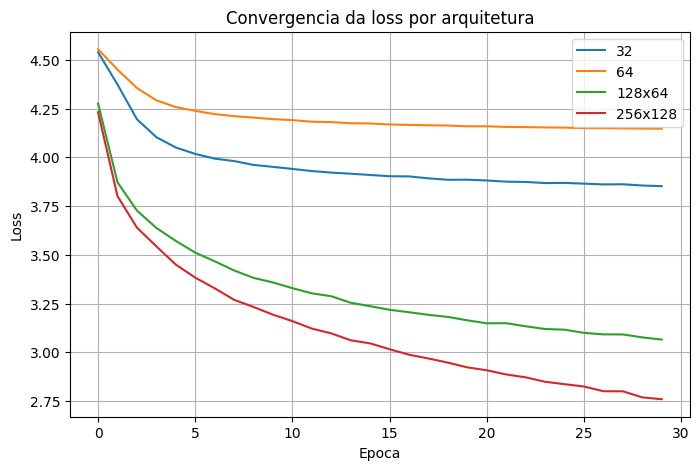

In [9]:
architectures = [(32,), (64,), (128, 64), (256, 128)]

arch_results = []
arch_models = {}

for arch in architectures:
    name = "x".join(str(n) for n in arch)
    model, metrics = run_experiment(
        run_name=f"arch_{name}",
        activation="relu",
        hidden_layers=arch,
        learning_rate=0.001,
    )
    # Accuracy no treino ajuda a perceber overfitting.
    metrics["train_accuracy"] = model.score(X_train, y_train)
    arch_models[name] = model
    arch_results.append(metrics)

df_arch = pd.DataFrame(arch_results)[
    ["run_name", "accuracy", "train_accuracy", "f1_score", "training_time"]
]
df_arch["gap_treino_val"] = df_arch["train_accuracy"] - df_arch["accuracy"]
display(df_arch)

plt.figure(figsize=(8, 5))
for name, model in arch_models.items():
    plt.plot(model.loss_curve_, label=name)
plt.title("Convergencia da loss por arquitetura")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Discussao**:

Comparei as quatro arquiteturas com tudo igual (relu, lr `0.001`, mesma seed).

Respondendo as perguntas:

1. **Redes maiores sempre melhoraram?** Nao. A `(64,)` ate ficou pior que a `(32,)` (0,0517
   contra 0,1006). O salto veio com a segunda camada: a `(128, 64)` foi pra 0,2054. O que pesou
   foi a profundidade, nao alargar uma camada so.

2. **Melhor tradeoff:** a `(128, 64)`, que entrega 0,2054 em uns 140s e com overfitting sob
   controle. A `(256, 128)` chega a 0,2238, mas cobra mais que o dobro do tempo.

3. **Sinais de overfitting?** Sim, crescem com o tamanho da rede: o gap treino-validacao vai de
   quase zero nas pequenas pra 0,093 na `(256, 128)` (treino 0,317 contra 0,224 na validacao).

4. **Maior custo computacional:** a `(256, 128)`, com ~313s, quase 9 vezes o tempo da menor.

# Questão 7

Compare os seguintes learning rates:

```python
0.1
0.01
0.001
```

## Requisitos

Utilize:

- mesma arquitetura;
- mesma ativação;
- mesma seed.

Para cada experimento:

- treine;
- avalie;
- registre no MLflow.

Analise:

- estabilidade;
- convergência;
- accuracy;
- comportamento da loss.

Responda:

1. Qual learning rate apresentou melhor desempenho?
2. Qual apresentou maior instabilidade?
3. O que acontece quando o learning rate é muito alto?
4. O que acontece quando o learning rate é muito baixo?

**Solucao**:

Por fim, comparo tres learning rates (`0.1`, `0.01`, `0.001`) com tudo o resto fixo:
arquitetura `(128, 64)`, ativacao relu e mesma seed. A ideia e ver como o tamanho do passo
muda a convergencia e a estabilidade do treino, olhando tanto as metricas quanto a curva
de loss.

,run_name,accuracy,f1_score,training_time
0,lr_0.1,0.0100,0.000198,233.841573
1,lr_0.01,0.0100,0.000198,58.195287
2,lr_0.001,0.2054,0.191659,120.924157


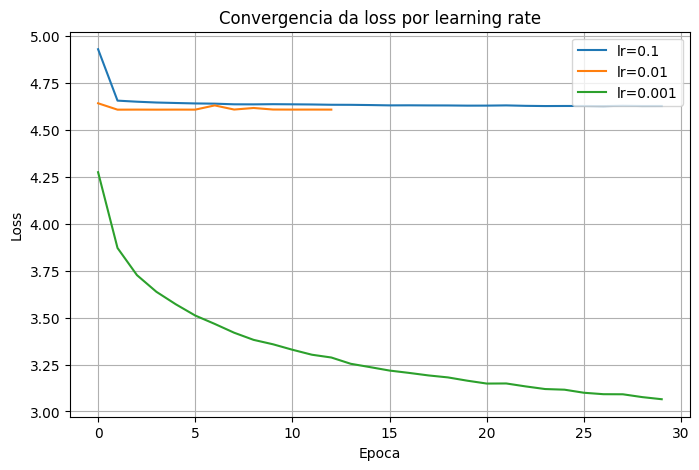

In [10]:
learning_rates = [0.1, 0.01, 0.001]

lr_results = []
lr_models = {}

for lr in learning_rates:
    model, metrics = run_experiment(
        run_name=f"lr_{lr}",
        activation="relu",
        hidden_layers=(128, 64),
        learning_rate=lr,
    )
    lr_models[lr] = model
    lr_results.append(metrics)

df_lr = pd.DataFrame(lr_results)[["run_name", "accuracy", "f1_score", "training_time"]]
display(df_lr)

plt.figure(figsize=(8, 5))
for lr, model in lr_models.items():
    plt.plot(model.loss_curve_, label=f"lr={lr}")
plt.title("Convergencia da loss por learning rate")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Discussao**:

Mesma `(128, 64)`, mesma relu e mesma seed, variando so o learning rate. O `0.001` foi o unico
que aprendeu (0,2054 de accuracy). O `0.01` e o `0.1` empacaram nos 0,0100, ou seja, no chute.

Respondendo as perguntas:

1. **Melhor desempenho:** o lr `0.001`, disparado, com 0,2054.

2. **Maior instabilidade:** o `0.1` e o `0.01`, que despencaram pra 0,0100 (o acaso em 100
   classes). Com passo grande demais a rede nao aprendeu nada.

3. **Quando o lr e muito alto:** os passos ficam grandes demais e o modelo passa por cima do
   minimo; a loss nao desce e o treino trava. Aqui ate o `0.01`, que no CIFAR-10 ainda aprendia
   algo, ja foi alto demais.

4. **Quando o lr e muito baixo:** os passos ficam pequenos e o treino fica lento, precisando de
   mais epocas. O `0.001` foi o equilibrio pra essas 30 epocas.

# Questão 8

Com base nos experimentos realizados, escreva uma discussão contendo:

- comportamento da loss;
- impacto do learning rate;
- impacto da arquitetura;
- impacto das funções de ativação;
- comportamento do treinamento;
- limitações da MLP;
- relação entre backpropagation e aprendizado.

Além disso, responda:

1. Qual configuração apresentou melhor resultado final?
2. Quais foram as principais dificuldades observadas?
3. Por que MLPs possuem limitações para imagens?
4. Como o backpropagation contribui para o aprendizado da rede?

# Discussao final

**Comportamento da loss.** Com relu e lr `0.001` ela caiu de forma suave; com lr alto demais
(`0.1` e `0.01`) nem desceu, e o modelo travou no acaso (1%). A curva ja conta a historia do
treino.

**Impacto do learning rate.** Foi o mais sensivel de todos: o `0.001` aprendeu (0,2054) e os
maiores quebraram o treino (0,0100). Alto demais diverge, baixo demais aprende devagar.

**Impacto da arquitetura.** Ajudou ate certo ponto. As redes de uma camada foram fracas (a
`(64,)` ate abaixo da `(32,)`); o salto veio com a segunda camada. A `(256, 128)` rendeu um
pouco mais, mas custou o dobro do tempo e o maior overfitting.

**Impacto das ativacoes.** A relu (0,2054) ganhou da tanh (0,1740) e da logistic (0,1739), por
ser barata e nao saturar nos positivos, evitando o gradiente que some.

**Comportamento do treinamento.** Estavel num intervalo razoavel de hiperparametros; instavel
nos extremos de lr, e com o overfitting crescendo conforme a rede aumentava.

**Limitacoes da MLP.** Com o flatten ela perde a estrutura espacial da imagem, explode em
parametros e nao compartilha pesos. Por isso a accuracy travou nos 20%, onde uma CNN iria bem
mais longe, ainda mais com 100 classes parecidas.

**Backpropagation.** Depois do forward pass, ele usa a regra da cadeia pra ver o quanto cada
peso contribuiu pro erro, e o otimizador (Adam) ajusta os pesos pra reduzir a loss. Esse ciclo,
repetido a cada epoca, e o que faz a rede aprender.

Respondendo as perguntas:

1. **Melhor resultado final:** a `(256, 128)` com relu e lr `0.001` (0,2238). Mas, pelo custo, a
   `(128, 64)` (0,2054 na metade do tempo e com menos overfitting) e a escolha mais esperta.

2. **Principais dificuldades:** o teto baixo da MLP em imagens (pior ainda no CIFAR-100), a
   sensibilidade ao learning rate e o overfitting que cresceu com o tamanho da rede.

3. **Por que MLPs tem limitacoes para imagens:** porque ignoram a estrutura espacial. Com o
   flatten some a vizinhanca dos pixels, os parametros disparam e nao ha compartilhamento de
   pesos, entao elas nao enxergam bordas e texturas como uma CNN.

4. **Como o backpropagation contribui:** ele distribui a culpa do erro entre os pesos via regra
   da cadeia, indicando pra que lado ajustar cada um. Sem ele nao daria pra treinar as camadas
   escondidas de forma eficiente.